In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos procesados
daily = pd.read_csv("../data/processed/eurusd_daily_procesado.csv", 
                    index_col=0, parse_dates=True)

print(f"Datos cargados: {daily.shape}")
print(daily.columns.tolist())
print(daily.tail(3))

Datos cargados: (4230, 8)
['Close', 'High', 'Low', 'Open', 'Volume', 'returns', 'volatility_20', 'volatility_60']
               Close      High       Low      Open  Volume   returns  \
Date                                                                   
2026-04-01  1.157421  1.162656  1.155588  1.157113       0  0.009916   
2026-04-02  1.159057  1.159878  1.151039  1.159152       0  0.001413   
2026-04-03  1.152871  1.155135  1.152605  1.154601       0 -0.005352   

            volatility_20  volatility_60  
Date                                      
2026-04-01       0.087105       0.075825  
2026-04-02       0.086933       0.075873  
2026-04-03       0.088552       0.076570  


In [2]:
# ── RSI (14 períodos) ──────────────────────────────────────────
delta = daily['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
daily['rsi_14'] = 100 - (100 / (1 + rs))

# ── ATR (14 períodos) ──────────────────────────────────────────
high_low = daily['High'] - daily['Low']
high_close = (daily['High'] - daily['Close'].shift(1)).abs()
low_close = (daily['Low'] - daily['Close'].shift(1)).abs()
true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
daily['atr_14'] = true_range.rolling(14).mean()

# ── Bollinger Bands (20 períodos) ──────────────────────────────
daily['bb_mid'] = daily['Close'].rolling(20).mean()
daily['bb_std'] = daily['Close'].rolling(20).std()
daily['bb_upper'] = daily['bb_mid'] + 2 * daily['bb_std']
daily['bb_lower'] = daily['bb_mid'] - 2 * daily['bb_std']
daily['bb_width'] = (daily['bb_upper'] - daily['bb_lower']) / daily['bb_mid']
daily['bb_position'] = (daily['Close'] - daily['bb_lower']) / (daily['bb_upper'] - daily['bb_lower'])

# ── Medias móviles ─────────────────────────────────────────────
daily['sma_20'] = daily['Close'].rolling(20).mean()
daily['sma_50'] = daily['Close'].rolling(50).mean()
daily['sma_200'] = daily['Close'].rolling(200).mean()
daily['ema_12'] = daily['Close'].ewm(span=12).mean()
daily['ema_26'] = daily['Close'].ewm(span=26).mean()

# ── MACD ───────────────────────────────────────────────────────
daily['macd'] = daily['ema_12'] - daily['ema_26']
daily['macd_signal'] = daily['macd'].ewm(span=9).mean()
daily['macd_hist'] = daily['macd'] - daily['macd_signal']

print(f"Features construidos: {daily.shape[1]} columnas")
print(daily.columns.tolist())

Features construidos: 24 columnas
['Close', 'High', 'Low', 'Open', 'Volume', 'returns', 'volatility_20', 'volatility_60', 'rsi_14', 'atr_14', 'bb_mid', 'bb_std', 'bb_upper', 'bb_lower', 'bb_width', 'bb_position', 'sma_20', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'macd', 'macd_signal', 'macd_hist']


In [3]:
# ── Momentum ───────────────────────────────────────────────────
daily['momentum_5'] = daily['Close'].pct_change(5)
daily['momentum_10'] = daily['Close'].pct_change(10)
daily['momentum_20'] = daily['Close'].pct_change(20)

# ── Posición relativa del precio ───────────────────────────────
daily['high_20'] = daily['High'].rolling(20).max()
daily['low_20'] = daily['Low'].rolling(20).min()
daily['price_position'] = (daily['Close'] - daily['low_20']) / (daily['high_20'] - daily['low_20'])

# ── Relación entre medias (señal de tendencia) ─────────────────
daily['trend_20_50'] = daily['sma_20'] / daily['sma_50'] - 1
daily['trend_50_200'] = daily['sma_50'] / daily['sma_200'] - 1

# ── Retornos rezagados (para PatchTST y HMM) ──────────────────
for lag in [1, 2, 3, 5, 10]:
    daily[f'return_lag_{lag}'] = daily['returns'].shift(lag)

# ── Eliminar NaN ───────────────────────────────────────────────
daily_clean = daily.dropna()

print(f"Features totales: {daily_clean.shape[1]} columnas")
print(f"Filas después de limpiar NaN: {len(daily_clean)}")
print(f"Período: {daily_clean.index[0].date()} → {daily_clean.index[-1].date()}")

Features totales: 37 columnas
Filas después de limpiar NaN: 4031
Período: 2010-10-08 → 2026-04-03


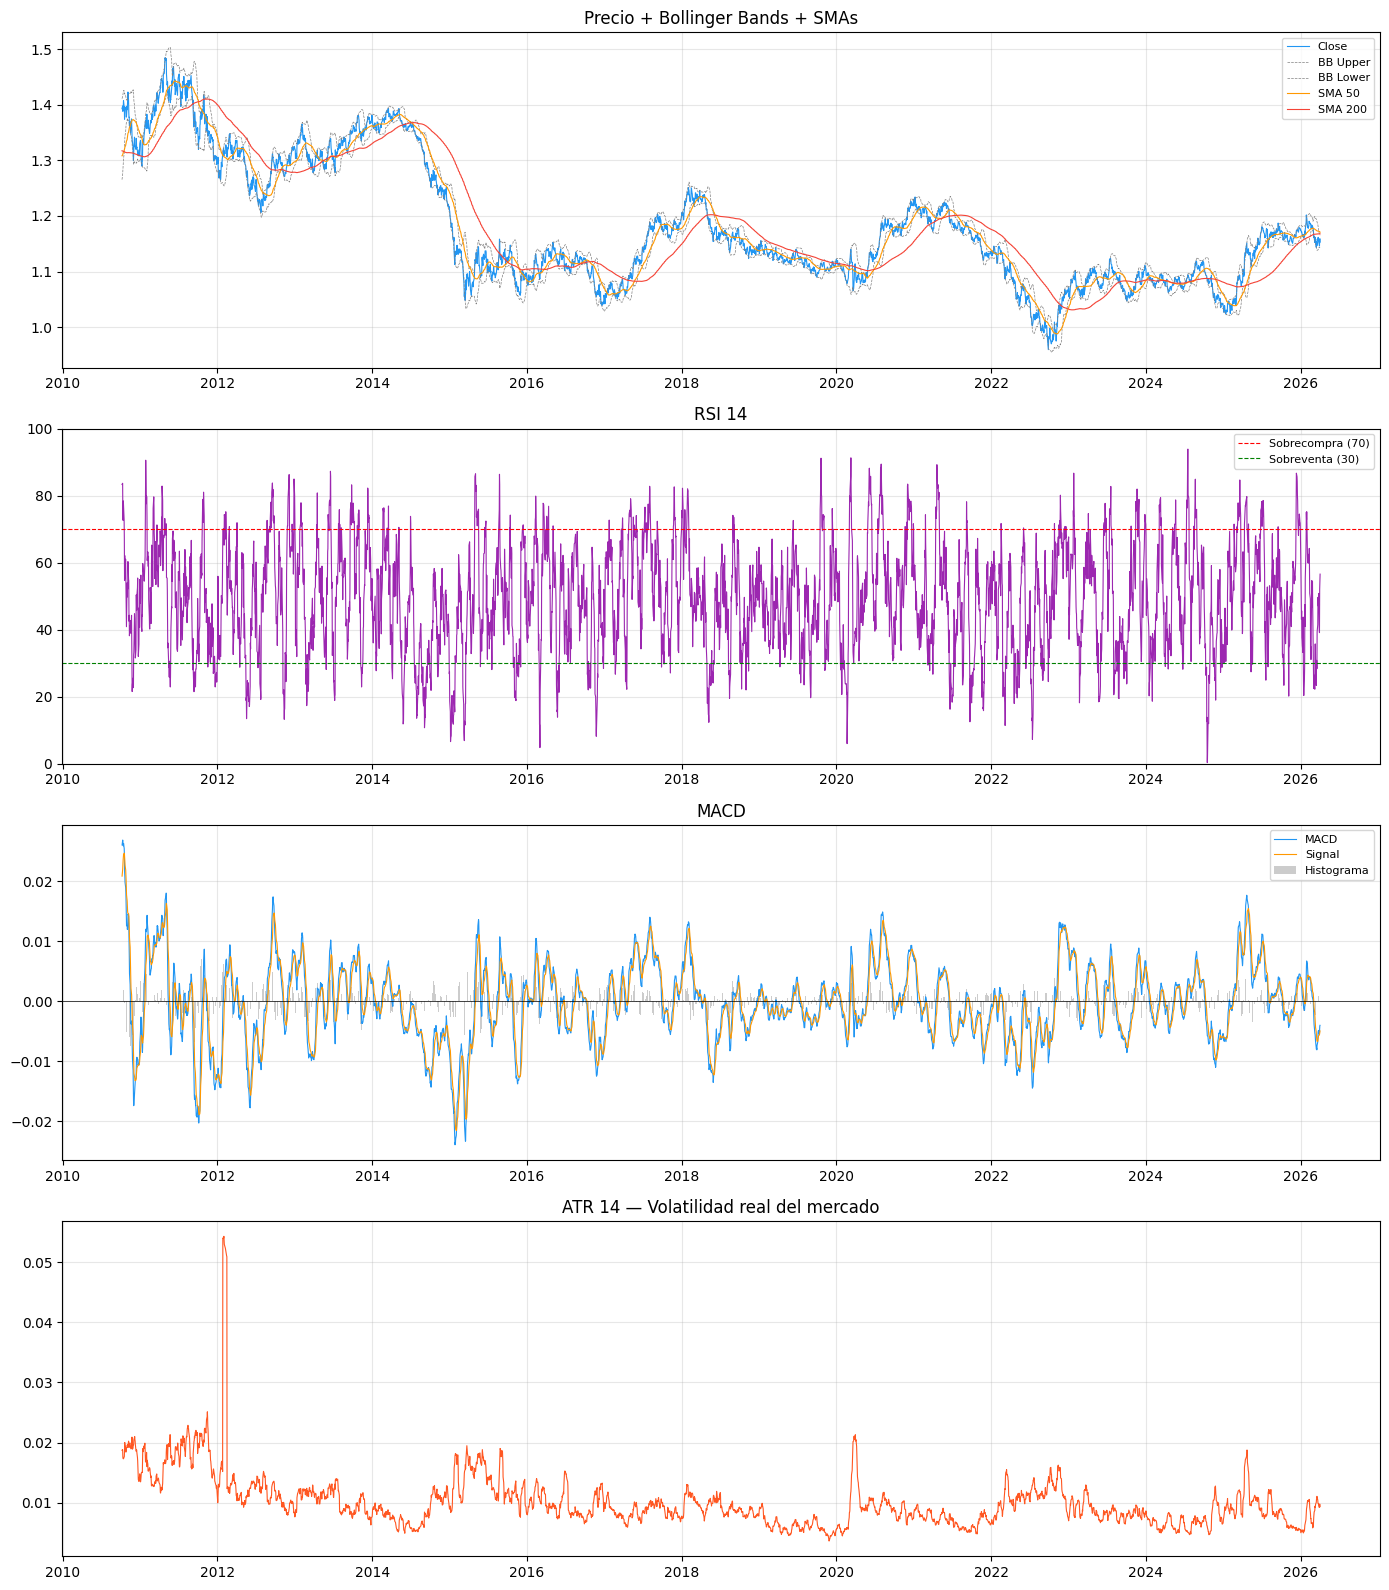

Gráfica guardada.


In [4]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

# Precio + Bollinger Bands + SMAs
axes[0].plot(daily_clean.index, daily_clean['Close'], color='#2196F3', linewidth=0.8, label='Close')
axes[0].plot(daily_clean.index, daily_clean['bb_upper'], color='gray', linewidth=0.5, linestyle='--', label='BB Upper')
axes[0].plot(daily_clean.index, daily_clean['bb_lower'], color='gray', linewidth=0.5, linestyle='--', label='BB Lower')
axes[0].plot(daily_clean.index, daily_clean['sma_50'], color='#FF9800', linewidth=0.8, label='SMA 50')
axes[0].plot(daily_clean.index, daily_clean['sma_200'], color='#F44336', linewidth=0.8, label='SMA 200')
axes[0].set_title('Precio + Bollinger Bands + SMAs', fontsize=12)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# RSI
axes[1].plot(daily_clean.index, daily_clean['rsi_14'], color='#9C27B0', linewidth=0.8)
axes[1].axhline(70, color='red', linewidth=0.8, linestyle='--', label='Sobrecompra (70)')
axes[1].axhline(30, color='green', linewidth=0.8, linestyle='--', label='Sobreventa (30)')
axes[1].set_title('RSI 14', fontsize=12)
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# MACD
axes[2].plot(daily_clean.index, daily_clean['macd'], color='#2196F3', linewidth=0.8, label='MACD')
axes[2].plot(daily_clean.index, daily_clean['macd_signal'], color='#FF9800', linewidth=0.8, label='Signal')
axes[2].bar(daily_clean.index, daily_clean['macd_hist'], color='gray', alpha=0.4, label='Histograma')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('MACD', fontsize=12)
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

# ATR
axes[3].plot(daily_clean.index, daily_clean['atr_14'], color='#FF5722', linewidth=0.8)
axes[3].set_title('ATR 14 — Volatilidad real del mercado', fontsize=12)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/04_features_tecnicos.png', dpi=150)
plt.show()
print("Gráfica guardada.")

In [5]:
# Guardar features completos
daily_clean.to_csv("../data/processed/eurusd_features.csv")

print(f"Features guardados: {daily_clean.shape}")
print(f"Columnas: {daily_clean.columns.tolist()}")

Features guardados: (4031, 37)
Columnas: ['Close', 'High', 'Low', 'Open', 'Volume', 'returns', 'volatility_20', 'volatility_60', 'rsi_14', 'atr_14', 'bb_mid', 'bb_std', 'bb_upper', 'bb_lower', 'bb_width', 'bb_position', 'sma_20', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'macd', 'macd_signal', 'macd_hist', 'momentum_5', 'momentum_10', 'momentum_20', 'high_20', 'low_20', 'price_position', 'trend_20_50', 'trend_50_200', 'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5', 'return_lag_10']
